# NEET 2024

In [6]:
import numpy as np
import pandas as pd

dataset = pd.read_csv("all_data.csv")
dataset.dropna()
dataset.info

<bound method DataFrame.info of          center_id                                        center_name  \
0           272807  KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...   
1           272807  KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...   
2           272807  KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...   
3           272807  KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...   
4           272807  KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...   
...            ...                                                ...   
2333157     250301  AYESHA ALI ACADEMY, KANIPORA KULGAM, J&K, ANAN...   
2333158     250301  AYESHA ALI ACADEMY, KANIPORA KULGAM, J&K, ANAN...   
2333159     250301  AYESHA ALI ACADEMY, KANIPORA KULGAM, J&K, ANAN...   
2333160     250301  AYESHA ALI ACADEMY, KANIPORA KULGAM, J&K, ANAN...   
2333161     250301  AYESHA ALI ACADEMY, KANIPORA KULGAM, J&K, ANAN...   

                 center_city     center_state  serial_no  score  
0        SHIVAMOGA (SHIMO

In [44]:
dataset.describe().round(3)

,center_id,serial_no,score,Rank
count,2333162.000,2333162.000,2333162.000,2333162.000
mean,322402.048,290.234,217.157,1163725.674
std,104959.799,217.144,166.240,672164.038
min,110101.000,1.000,-180.000,1.000
25%,260202.000,124.000,87.000,581722.000
50%,311119.000,251.000,163.000,1165724.000
75%,412206.000,408.000,313.000,1749236.000
max,991401.000,1968.000,720.000,2333161.000


## acc to shiksha.com the cutoffs for neet 2024 were calculated based on
#### 1. For Unreserved/General - 50th percentile of marks meaning the cutoff range is 720 - 164
#### 2. For SC/ST/OBC - 40th percentile of marks meaning the cutoff range is 161 - 127

In [11]:
# finding cutoff based on given score from the data
scores = dataset["score"]

general = np.percentile(scores, 50)
reserved = np.percentile(scores, 40)

print("General cutoff 2024: ", general)
print("Reserved cutoff 2024: ", reserved)

General cutoff 2024:  163.0
Reserved cutoff 2024:  128.0


In [19]:
# calculating Ranks using the dataset

dataset['Rank'] = dataset["score"].rank(ascending=False, method='min').astype(int)
dataset = dataset.sort_values(by='Rank').reset_index(drop=True)
print("Top 15 ranked")
dataset.head(15)

Top 15 ranked


,center_id,center_name,center_city,center_state,serial_no,score,Rank
0,410801,"PAAVAI ENGINEERING COLLEGE, NH-44 PACHAL (PO) ...",NAMAKKAL,TAMIL NADU,414,720,1
1,311120,"MODERN SCHOOL, OPP SUNDER BISCUIT FACTORY 8TH ...",NAGPUR,MAHARASHTRA,460,720,1
2,390601,"ST. ANTHONYS SR. SEC. SCHOOL, GOVERDHAN VILAS ...",UDAIPUR,RAJASTHAN,459,720,1
3,220106,"SHREE NARAYANA CENTRAL SCHOOL, OPP ISRO JODHPU...",AHMEDABAD,GUJARAT,458,720,1
4,311250,"MATOSHRI PRATISHTHAN, VISHWABHARATI POLTTECHNI...",NANDED,MAHARASHTRA,147,720,1
5,271216,"NAGARJUNA VIDYANIKETAN, #104 IVRI ROAD BEHIND ...",BENGALURU- URBAN,KARNATAKA,158,720,1
6,390527,"DECENT SCHOOL, DEOLI ARAB-RAIPURA ROAD-RAJNAGA...",KOTA,RAJASTHAN,165,720,1
7,280826,"SAPPHIRE CENTRAL SCHOOL, PEACE VALLEY CAMPUS M...",KOZHIKODE/CALICUT,KERALA,43,720,1
8,390301,"ALPHA INTERNATIONAL ACADEMY, KATARIA FARM, VIS...",JAIPUR,RAJASTHAN,691,720,1
9,392344,"SARASWATI PUBLIC SCHOOL, BEHIND KAMALA MODI MA...",SIKAR,RAJASTHAN,212,720,1


## checking eligibility for top Medical Colleges, closing ranks
### 1. AIIMS Delhi - 47
### 2. AIIMS Bhopal - 79
### 3. AIIMS Rishikesh - 594
### 4. AIIMS Bhubaneshwar - 655
### 5. AIIMS Nagpur - 953

In [ ]:
dataset['AIIMS Delhi'] = dataset['Rank'].apply(lambda x: 'Eligible' if x < 47 else 'Not Eligible')
dataset['AIIMS Bhopal'] = dataset['Rank'].apply(lambda x: 'Eligible' if x < 79 else 'Not Eligible')
dataset['AIIMS Rishikesh'] = dataset['Rank'].apply(lambda x: 'Eligible' if x < 594 else 'Not Eligible')
dataset['AIIMS Bhubaneshwar'] = dataset['Rank'].apply(lambda x: 'Eligible' if x < 655 else 'Not Eligible')
dataset['AIIMS Nagpur'] = dataset['Rank'].apply(lambda x: 'Eligible' if x < 953 else 'Not Eligible')

dataset.iloc[150:350]

In [42]:
dataset.iloc[950:965]

,center_id,center_name,center_city,center_state,serial_no,score,Rank,AIIMS Delhi,AIIMS Bhopal,AIIMS Rishikesh,AIIMS Bhubaneshwar,AIIMS Nagpur,Score Range
950,444603,"SETH CHANNURAM BAJAJ MEMORIAL PUBLIC SCHOOL, N...",MAINPURI,UTTAR PRADESH,149,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
951,122004,"SUBHANIKETAN SCHOOL, NEAR JEWEL MEADOW APARTME...",KAKINADA,ANDHRA PRADESH,171,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
952,120514,"SRI VIJNAN VIHARA EM SCHOOL, BESIDE DECOTHLON ...",VIJAYAWADA,ANDHRA PRADESH,294,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
953,390505,"LAWRENCE AND MAYO PUBLIC SCHOOL, SECTOR A SRIN...",KOTA,RAJASTHAN,588,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
954,420802,"ZEE HIGH SCHOOL HAYATHNAGAR, LANE BESIDE CANAR...",HAYATHNAGAR,TELANGANA,127,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
955,120507,"VIKAS GROUP OF INSTITUTIONS, LOYABATA ROAD NUN...",VIJAYAWADA,ANDHRA PRADESH,301,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
956,410609,"OM SADHANA CENTRAL SCHOOL, T.P.M. NAGAR,THENI ...",MADURAI,TAMIL NADU,314,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
957,410113,SAN ACADEMY AGS COLONY PALLIKARANAI CHENNAI TN...,CHENNAI,TAMIL NADU,324,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
958,392321,"BHARTIYA MAHILA P.G. MAHAVIDYALAYA, NEAR SANWA...",SIKAR,RAJASTHAN,89,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720
959,390551,"SOPHIA SR. SEC. SCHOOL, NEW RLY. COLONY, KOTA,...",KOTA,RAJASTHAN,228,705,833,Not Eligible,Not Eligible,Not Eligible,Not Eligible,Eligible,700-720


### Rank vs Score plot

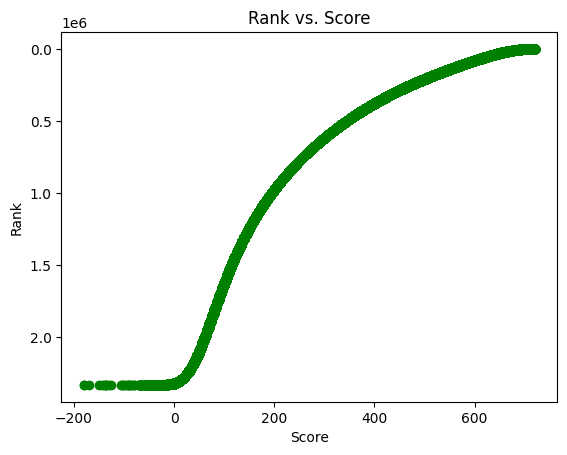

In [24]:
import matplotlib.pyplot as plt

plt.plot(dataset["score"], dataset["Rank"], marker='o', linestyle='--', color='green')
plt.title("Rank vs. Score")
plt.xlabel("Score")
plt.ylabel("Rank")
plt.gca().invert_yaxis()
plt.show()

## Score Range

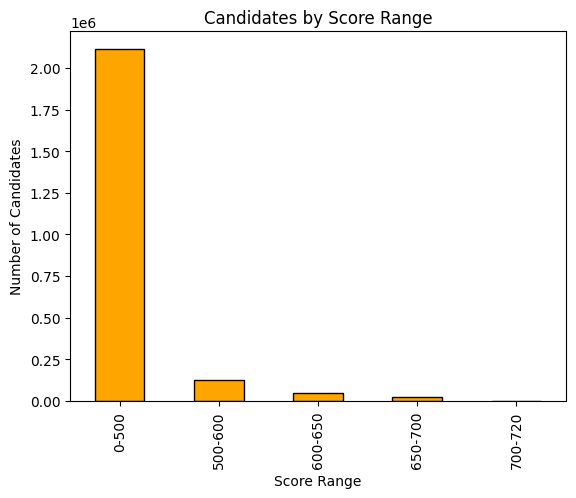

In [27]:
bins = [0, 500, 600, 650, 700, 720]
labels = ['0-500', '500-600', '600-650', '650-700', '700-720']
dataset['Score Range'] = pd.cut(dataset['score'], bins=bins, labels=labels)

score_range_counts = dataset['Score Range'].value_counts(sort=False)

score_range_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Candidates by Score Range")
plt.xlabel("Score Range")
plt.ylabel("Number of Candidates")
plt.show()


## Distribution of candidates eligible for top 5 aiims 

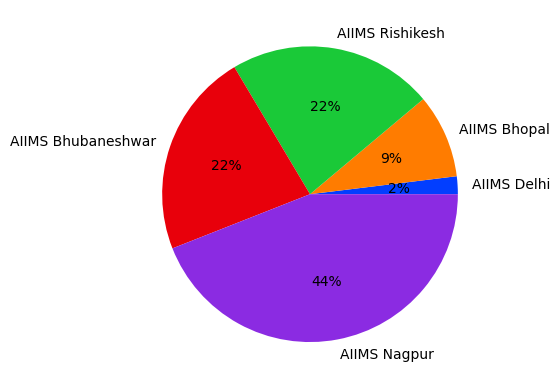

In [41]:
eligible1 = (dataset["AIIMS Delhi"] == "Eligible").sum()
eligible2 = (dataset["AIIMS Bhopal"] == "Eligible").sum()
eligible3 = (dataset["AIIMS Rishikesh"] == "Eligible").sum()
eligible4 = (dataset["AIIMS Bhubaneshwar"] == "Eligible").sum()
eligible5 = (dataset["AIIMS Nagpur"] == "Eligible").sum()

import seaborn
palette_color = seaborn.color_palette('bright')

pieData = [eligible1, eligible2, eligible3, eligible4, eligible5]
keys = ["AIIMS Delhi","AIIMS Bhopal" ,"AIIMS Rishikesh" ,"AIIMS Bhubaneshwar" ,"AIIMS Nagpur"]
plt.pie(pieData, labels=keys, colors=palette_color, autopct='%.0f%%') 
plt.show()


## Histogram to distribute scores

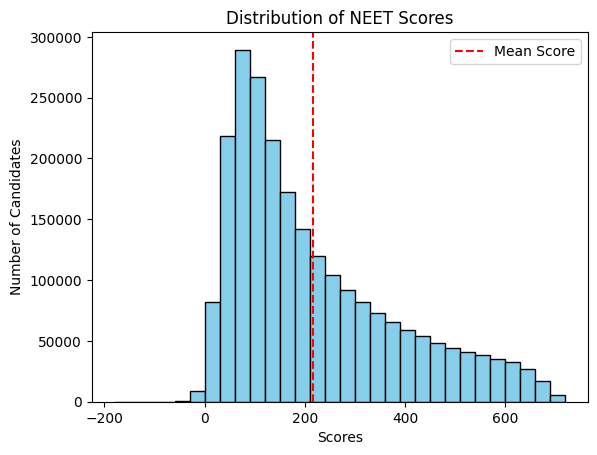

In [46]:
plt.hist(dataset["score"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of NEET Scores")
plt.xlabel("Scores")
plt.ylabel("Number of Candidates")
plt.axvline(dataset["score"].mean(), color='red', linestyle='dashed', label='Mean Score')
plt.legend()
plt.show()

## Heatmap

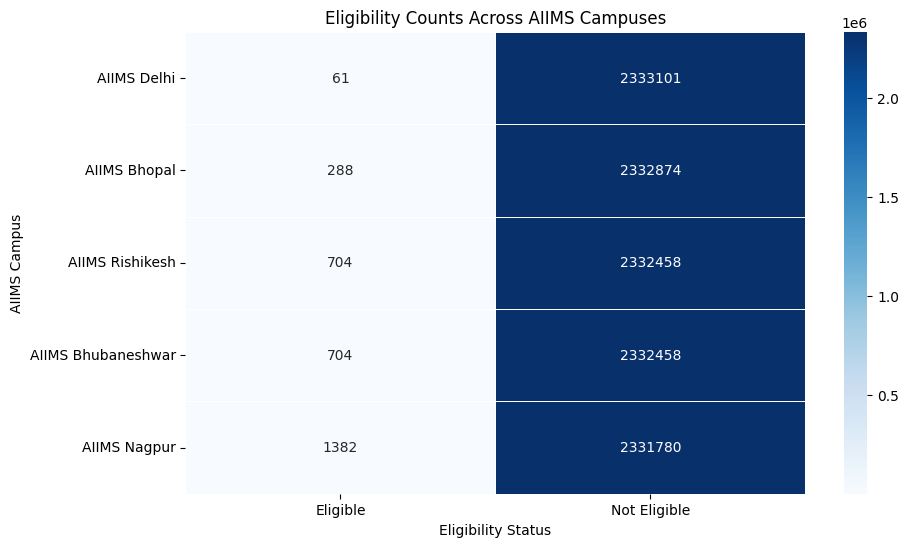

In [49]:
import seaborn as sns
heatmap_data = pd.DataFrame({
    "Eligible": [
        (dataset["AIIMS Delhi"] == "Eligible").sum(),
        (dataset["AIIMS Bhopal"] == "Eligible").sum(),
        (dataset["AIIMS Rishikesh"] == "Eligible").sum(),
        (dataset["AIIMS Bhubaneshwar"] == "Eligible").sum(),
        (dataset["AIIMS Nagpur"] == "Eligible").sum()
    ],
    "Not Eligible": [
        (dataset["AIIMS Delhi"] == "Not Eligible").sum(),
        (dataset["AIIMS Bhopal"] == "Not Eligible").sum(),
        (dataset["AIIMS Rishikesh"] == "Not Eligible").sum(),
        (dataset["AIIMS Bhubaneshwar"] == "Not Eligible").sum(),
        (dataset["AIIMS Nagpur"] == "Not Eligible").sum()
    ]
}, index=["AIIMS Delhi", "AIIMS Bhopal", "AIIMS Rishikesh", "AIIMS Bhubaneshwar", "AIIMS Nagpur"])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="Blues", linewidths=0.5, fmt="d")
plt.title("Eligibility Counts Across AIIMS Campuses")
plt.xlabel("Eligibility Status")
plt.ylabel("AIIMS Campus")
plt.show()


# Exporting to Excel